# AI English Analyzer мерзімін ықтималдықпен болжау
№6 зертханалық жұмыс. Автор: Ақжан Расуул, АЖ-37. Есеп күні: 07.10.2026.

**Дерек көзі:** берілген «Методичка по лабораторным работам (для студентов)» құжатының ЛЗ 6 бөліміндегі Python мысалы. Бұл — 26 шартты аптаның оқу қатары, жобаның нақты throughput тарихы емес. Күнтізбелік бастапқы кезең құжатта көрсетілмеген; week_index 1–26 қолданылады. Жобаға қатысты болжамдар осы қатардың жарамдылығы шартына тәуелді.

**Көлем:** ЛЗ4-тегі AEA-US-01–14, бар прототипті жетілдіру және қабылдау. Кодтың болуы Done дәлелі емес. Қабылданған тарихтар тізімі берілмегендіктен, бастапқы сценарийде 0 accepted және N=14 алынды. Бұл GitHub Issues-тен өлшенген қалдық емес. R2 тарихтары 15–18 есепке кірмейді.

**Тексерілген код:** main, 8c22a47e8ba3dba4e5f5a921482dcb9a6c58efd2. plan/generate API 7 күн құрады; aiClient 28 күнді сипаттайды. US-07/08 осы айырманы жою мен қабылдауды қамтиды.

Run All барлық ұяшықты ретімен орындайды. Басталу күні тұрақты бекітілген; кейінгі есепте START_DATE пен деректерді жаңарту керек.

In [1]:
from pathlib import Path
from datetime import date, timedelta
import json, math, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "data/throughput.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Notebook-ты репозиторийден ашыңыз: data/throughput.csv қажет")
OUT = ROOT / "docs/plan/lab6"
OUT.mkdir(parents=True, exist_ok=True)
START_DATE = date(2026, 10, 7)
RUNS, SEED = 10_000, 42
history_df = pd.read_csv(ROOT / "data/throughput.csv")
backlog = pd.read_csv(ROOT / "data/lab6_backlog.csv")
history = history_df["completed_items"].to_numpy()
assert len(history) > 0 and np.isfinite(history).all()
assert (history >= 0).all() and (history == np.floor(history)).all()
assert history.max() > 0, "Барлық апта нөл болса, аяқталу мерзімі анықталмайды"
history = history.astype(int)
assert backlog["story_id"].is_unique
assert backlog["accepted"].isin([True, False]).all()
remaining = backlog[(backlog["release"] == "MVP") & (~backlog["accepted"])]
N = len(remaining)
print(f"Күні: {START_DATE}; қалған көлем N={N}; runs={RUNS}; seed={SEED}")
print(f"Python {platform.python_version()}, NumPy {np.__version__}, pandas {pd.__version__}")

Күні: 2026-10-07; қалған көлем N=14; runs=10000; seed=42
Python 3.12.14, NumPy 2.3.5, pandas 2.2.3


## 1 Бастапқы деректерді талдау
Нөлдік апталар сақталады: олар бос тұрып қалу мүмкіндігін модельге енгізеді. Апта саны коммит санын білдірмейді.

In [2]:
stats = {"weeks": len(history), "sum": int(history.sum()),
         "mean": float(history.mean()), "median": float(np.median(history)),
         "min": int(history.min()), "max": int(history.max()),
         "zero_weeks": int((history == 0).sum())}
print(history_df.to_string(index=False))
print(json.dumps(stats, ensure_ascii=False, indent=2))
print("Қалған тарихтар:", ", ".join(remaining["story_id"]))

 week_index  completed_items
          1                4
          2                6
          3                0
          4                7
          5                5
          6                2
          7                6
          8                9
          9                4
         10                5
         11                0
         12                6
         13                7
         14                4
         15                5
         16                1
         17                6
         18                5
         19                9
         20                3
         21                4
         22                6
         23                5
         24                8
         25                2
         26                5
{
  "weeks": 26,
  "sum": 124,
  "mean": 4.769230769230769,
  "median": 5.0,
  "min": 0,
  "max": 9,
  "zero_weeks": 2
}
Қалған тарихтар: AEA-US-01, AEA-US-02, AEA-US-03, AEA-US-04, AEA-US-05, AEA-US-06, AEA-US-07, AE

## 2 Монте Карло алгоритмі
Әр прогонда тарихтан апталық өнімділік қайтарумен кездейсоқ таңдалады. Қосынды N-ге жеткенде апта саны тіркеледі. Әр апта тәуелсіз және тарих болашаққа жарамды деп жорамалданады. Тәуелділіктер мен сыртқы кідірістер жеке модельденбейді.

In [3]:
def simulate(history, n, runs=RUNS, seed=SEED):
    if n < 0:
        raise ValueError("N теріс болмауы керек")
    rng = np.random.default_rng(seed)
    weeks = np.zeros(runs, dtype=int)
    for i in range(runs):
        done, w = 0, 0
        while done < n:
            done += int(rng.choice(history))
            w += 1
            if w > 100_000:
                raise RuntimeError("Өнімділік тым төмен: деректерді тексеріңіз")
        weeks[i] = w
    return weeks

def summarize(samples):
    rows = []
    for p in (50, 70, 85, 95):
        # Эмпирикалық CDF кемінде p болатын ең ерте бүтін апта.
        w = int(np.quantile(samples, p / 100, method="inverted_cdf"))
        rows.append({"level": f"P{p}", "weeks": w,
                     "date": (START_DATE + timedelta(weeks=w)).isoformat(),
                     "empirical_probability": float((samples <= w).mean())})
    return rows

weeks = simulate(history, N)
results = summarize(weeks)
print(pd.DataFrame(results).to_string(index=False))
print(f"Орташаға бөлу: {N/history.mean():.2f} апта; жоғары дөңгелектеу {math.ceil(N/history.mean())} апта")
print(f"3 аптада аяқтау: {(weeks <= 3).mean():.2%}")
print(f"4 аптада аяқтау: {(weeks <= 4).mean():.2%}")

level  weeks       date  empirical_probability
  P50      3 2026-10-28                 0.5900
  P70      4 2026-11-04                 0.8805
  P85      4 2026-11-04                 0.8805
  P95      5 2026-11-11                 0.9706
Орташаға бөлу: 2.94 апта; жоғары дөңгелектеу 3 апта
3 аптада аяқтау: 59.00%
4 аптада аяқтау: 88.05%


## 3 Мерзім таралуының гистограммасы
Баған биіктігі осы аптада аяқталған прогондар санын көрсетеді. Ұзын оң жақ құйрық баяу және нөлдік апталардың әсерін көрсетеді. Ең жиі аяқталу уақыты кепілдендірілген мерзім емес.

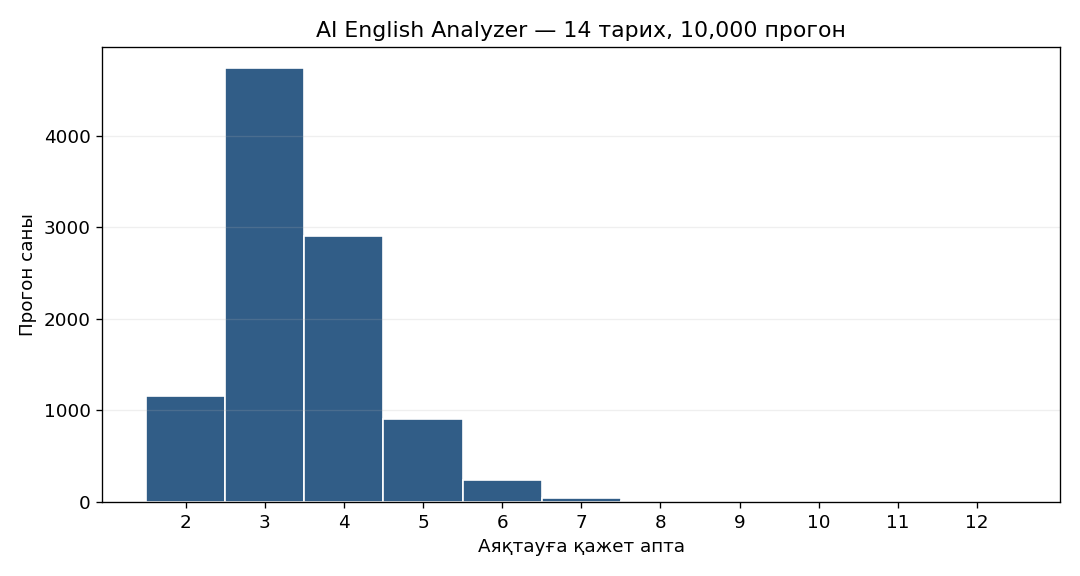

In [4]:
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})
fig, ax = plt.subplots(figsize=(9, 4.8))
bins = np.arange(weeks.min() - 0.5, weeks.max() + 1.5, 1)
ax.hist(weeks, bins=bins, color="#315D87", edgecolor="white")
ax.set(xticks=range(int(weeks.min()), int(weeks.max())+1),
       xlabel="Аяқтауға қажет апта", ylabel="Прогон саны",
       title=f"AI English Analyzer — {N} тарих, {RUNS:,} прогон")
ax.grid(axis="y", alpha=.2)
fig.tight_layout()
fig.savefig(OUT / "histogram.png", dpi=180)
plt.show()
plt.close(fig)

**Қорытынды:** таралудағы бірнеше мерзімді бірге қарастыру қажет. 3 аптада аяқталған немесе одан ерте аяқталған прогондар үлесі 59,00%; 4 аптаға дейін 88,05%.

## 4 Жинақталған ықтималдық қисығы
Көлденең ось — апта, тік ось — сол аптаға дейін аяқталу үлесі. Қисық сатылы: 70% және 85% деңгейлері бір аптаға сәйкес келуі мүмкін.

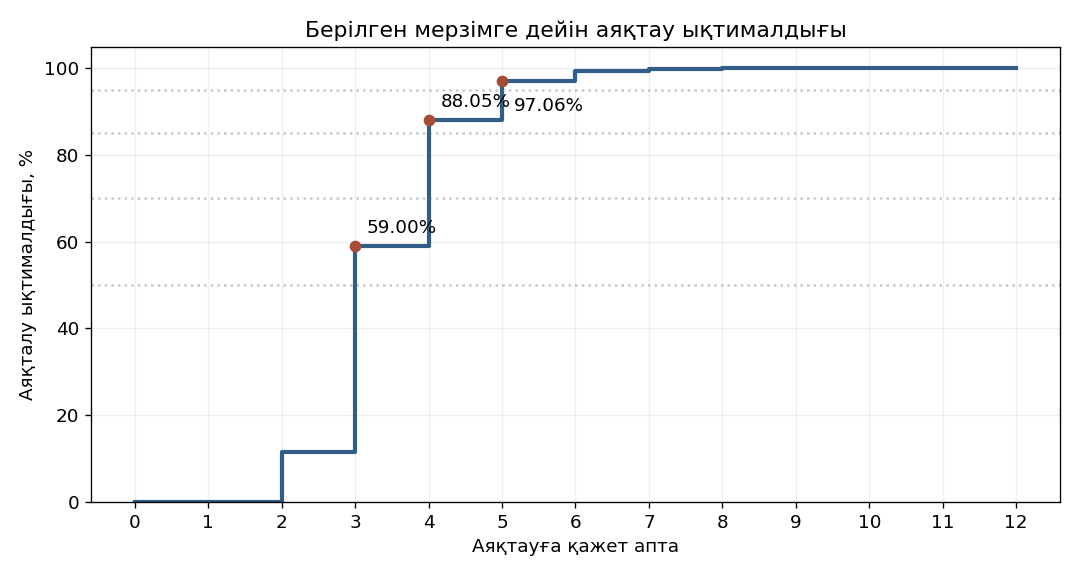

In [5]:
x = np.arange(0, int(weeks.max()) + 1)
y = np.array([(weeks <= w).mean() for w in x])
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.step(x, y*100, where="post", color="#315D87", linewidth=2.5)
ax.scatter([3,4,5], [(weeks <= w).mean()*100 for w in [3,4,5]], color="#A44C36", zorder=3)
for row in results:
    ax.axhline(int(row["level"][1:]), color="#777777", linestyle=":", alpha=.4)
for w in [3,4,5]:
    ax.annotate(f"{(weeks <= w).mean():.2%}", (w, (weeks <= w).mean()*100),
                xytext=(7,-18 if w==5 else 8), textcoords="offset points")
ax.set(xlabel="Аяқтауға қажет апта", ylabel="Аяқталу ықтималдығы, %",
       title="Берілген мерзімге дейін аяқтау ықтималдығы", ylim=(0,105), xticks=x)
ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(OUT / "cdf.png", dpi=180)
plt.show()
plt.close(fig)

**Қорытынды:** 07.10.2026 күнінен есептегенде P50 — 28.10.2026, P70 және P85 — 04.11.2026, P95 — 11.11.2026. P85 — 4 аптаға дейін аяқталу кемінде 85% болатын шек; осы симуляциядағы нақты үлес 88,05%. Бұл модель ішіндегі ықтималдық, сыртқы кепілдік емес.

## 5 Баламалар және сезімталдық
ЛЗ5 capacity ережесіне сай US-11, US-12, US-13 жетілдіруін R2-ге ауыстырғанда N=11 қалады. US-14 тек тест пен күндік тапсырмаларға шектеледі; жаттығу сессиясына тәуелділік алынады. Қолданыстағы код жойылмайды. Сыртқы оқу қатарының жылдамдығы оптимистік болуы мүмкін: әр аптадағы аяқталған санды төмен қарай екіге бөлу — тек стресс-сценарий, нақты калибрлеу емес. Нөлдерді алып тастау да салыстыру үшін ғана жасалады; негізгі есепте олар сақталады.

In [6]:
reduced_n = int(remaining["reduced_scope"].sum())
reduced = simulate(history, reduced_n)
slow_history = history // 2
slow = simulate(slow_history, N)
without_zeros = simulate(history[history > 0], N)
scenario_rows = []
for name, a, n in [("Негізгі", weeks, N), ("Қысқартылған", reduced, reduced_n),
                   ("Баяу стресс", slow, N), ("Нөлдерсіз салыстыру", without_zeros, N)]:
    row={"scenario":name,"N":n,"probability_by_3_weeks":float((a<=3).mean()),
         "probability_by_4_weeks":float((a<=4).mean())}
    row.update({r["level"]:r["weeks"] for r in summarize(a)})
    scenario_rows.append(row)
print(pd.DataFrame(scenario_rows).to_string(index=False))

           scenario  N  probability_by_3_weeks  probability_by_4_weeks  P50  P70  P85  P95
            Негізгі 14                  0.5900                  0.8805    3    4    4    5
       Қысқартылған 11                  0.8179                  0.9603    3    3    4    4
        Баяу стресс 14                  0.0000                  0.0105    7    7    8    9
Нөлдерсіз салыстыру 14                  0.7193                  0.9615    3    3    4    4


## 6 Story points бағасымен салыстыру
Жеке оқу бағасы: 14 тарих = 60 SP. Он тарихтың үш көзқарас бойынша үлгілік дауыстары planning-poker.md файлында берілген; басқа төрт тарих — бастапқы жеке баға. Нақты командалық покер сессиясы өткізілген жоқ. 10 SP/апта — өлшенбеген сценарийлік velocity; SP сағатқа тең емес. Бұл шартпен 60/10 = 6 апта, 18.11.2026. 15 SP/апта болса 4 апта, 8 SP/апта болса 8 апта. Айырмашылықтар дерек көздерінің, бағалау бірліктерінің және қабылдау шекараларының әртүрлі болуынан туындайды.

In [7]:
total_sp = int(remaining["story_points"].sum())
print("Барлық көлем:", total_sp, "SP")
for velocity in [8, 10, 15]:
    w = math.ceil(total_sp / velocity)
    print(f"{velocity} SP/апта: {w} апта; {START_DATE + timedelta(weeks=w)}")
forecast = {"start_date":str(START_DATE),"seed":SEED,"runs":RUNS,
            "base_commit":"8c22a47e8ba3dba4e5f5a921482dcb9a6c58efd2",
            "data_kind":"methodology_example_not_project_history", "stats":stats,
            "backlog":N,"story_points":total_sp,"results":results,
            "scenarios":scenario_rows,"next_review":"2026-10-14"}
(OUT / "forecast.json").write_text(json.dumps(forecast, ensure_ascii=False, indent=2)+"\n", encoding="utf-8")
pd.DataFrame(results).to_csv(OUT / "forecast.csv", index=False)
pd.DataFrame(scenario_rows).to_csv(OUT / "scenarios.csv", index=False)
# Есептің мағыналы инварианттары және дәл қайталануы.
assert np.array_equal(weeks, simulate(history, N))
assert len(weeks) == RUNS and (weeks > 0).all()
assert [r["weeks"] for r in results] == sorted(r["weeks"] for r in results)
assert all(r["empirical_probability"] >= int(r["level"][1:])/100 for r in results)
assert all((weeks < r["weeks"]).mean() < int(r["level"][1:])/100 for r in results)
print("Тексеру: тұрақты seed, 10 000 нәтиже, өспелі ықтималдық шектері — OK")

Барлық көлем: 60 SP
8 SP/апта: 8 апта; 2026-12-02
10 SP/апта: 6 апта; 2026-11-18
15 SP/апта: 4 апта; 2026-11-04
Тексеру: тұрақты seed, 10 000 нәтиже, өспелі ықтималдық шектері — OK


## 7 Жоспарға енгізілетін шешім
Ұсыныс: 14 тарихқа 04.11.2026 және 11.11.2026 күндерін шартты функционалдық қабылдау нүктелері ретінде көрсету. Ертерек көрсету керек болса, US-11–13 жетілдіруін кейінге қалдыру ұсынылады. Қысқартылған 11 тарих 3 аптада 81,79%, 4 аптада 96,03% үлесімен аяқталады; 3 аптаға 85% деп уәде беруге болмайды.

Толық эксплуатациялық тапсыруға арналған ЛЗ5-тегі 17.01.2027 межесі сақталады: қосымша сапа, миграция, оқыту және тапсыру осы 14 элементтік модельде бөлек есептелмеген. Нақты дерек жиналғанша бір адамның capacity жоспарынан бас тартуға болмайды.

Келесі қайта қарау — **14.10.2026**. Апталық Done санын, нөлдерді, N қалдығын және DoD өзгерісін тіркеу қажет. Нақты командада 8–12 апта дерек жиналғанда оқу қатарын алмастырып, ұқсас көлемдегі тарихтарға болжамды қайта есептеу ұсынылады.